In [2]:
import numpy as np
from scipy import stats


In [ ]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

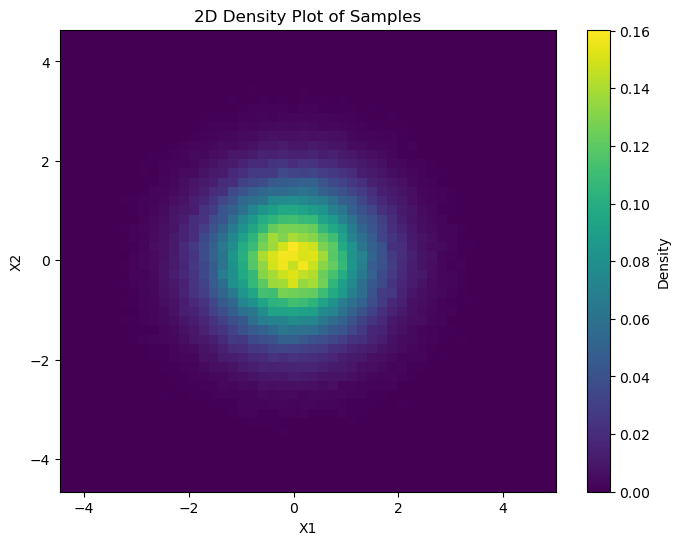

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def log_target_distribution(x):
    # Log of 2D Gaussian distribution
    return -0.5 * (x[0]**2 + x[1]**2) - np.log(2 * np.pi)

def proposal_distribution(x):
    # Example: 2D Gaussian centered at x with different variances
    return np.random.normal(x, [1, 2], size=2)

def log_proposal_density(x, y):
    # Log probability density of proposing y from x
    return -0.5 * (((y[0] - x[0]) / 1)**2 + ((y[1] - x[1]) / 2)**2) - np.log(2 * np.pi * 1 * 2)

def metropolis_hastings(log_target_dist, proposal_dist, log_proposal_dens, initial_state, num_samples):
    samples = [initial_state]
    current_state = initial_state

    for _ in range(num_samples - 1):
        proposed_state = proposal_dist(current_state)
        log_acceptance_ratio = (log_target_dist(proposed_state) + log_proposal_dens(proposed_state, current_state)) - \
                               (log_target_dist(current_state) + log_proposal_dens(current_state, proposed_state))
        
        if np.log(np.random.rand()) < log_acceptance_ratio:
            current_state = proposed_state
        
        samples.append(current_state)
    
    return np.array(samples)

# Parameters
initial_state = np.array([0, 0])
num_samples = 1000000

# Run Metropolis-Hastings
samples = metropolis_hastings(log_target_distribution, proposal_distribution, log_proposal_density, initial_state, num_samples)

# Generate 2D density plot
plt.figure(figsize=(8, 6))
plt.hist2d(samples[:, 0], samples[:, 1], bins=50, density=True, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('2D Density Plot of Samples')
plt.show()

(array([9.9982e+04, 1.4000e+01, 3.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([6.20646285e-02, 4.93245901e+01, 9.85871156e+01, 1.47849641e+02,
        1.97112167e+02, 2.46374692e+02]),
 <BarContainer object of 5 artists>)

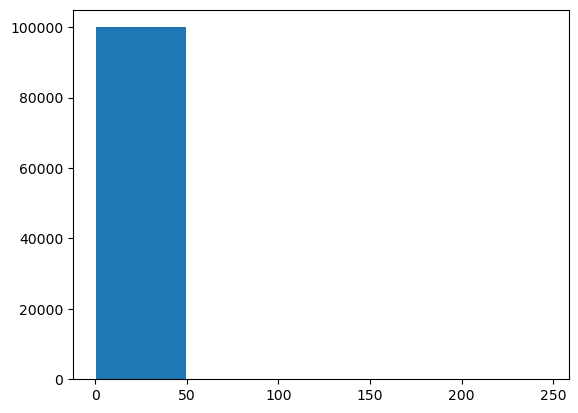

In [10]:
plt.hist(stats.invgamma.rvs(a= 2, size=100000), bins=5, )

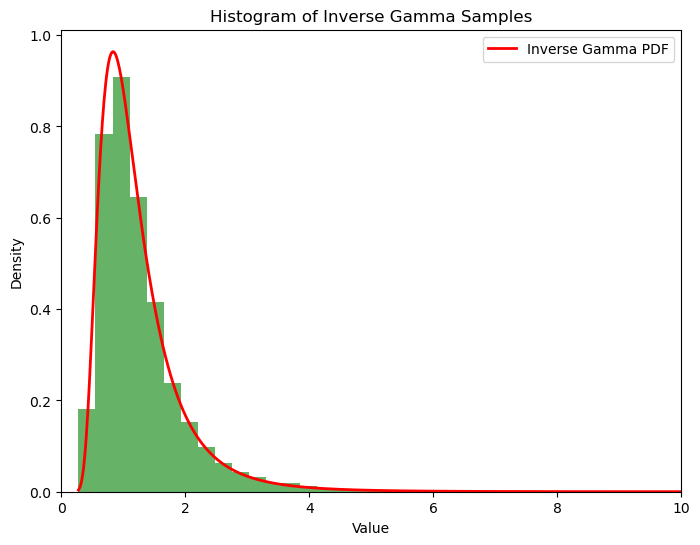

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Parameters for the inverse gamma distribution
shape_param = 5.0  # Shape parameter (alpha)
scale_param = 5.0  # Scale parameter (beta)

# Generate samples
num_samples = 10000
samples = invgamma.rvs(a=shape_param, scale=scale_param, size=num_samples)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')

# Plot the theoretical PDF
x = np.linspace(min(samples), max(samples), 1000)
pdf = invgamma.pdf(x, a=shape_param, scale=scale_param)
plt.plot(x, pdf, 'r-', lw=2, label='Inverse Gamma PDF')

# Limit x-axis to 50
plt.xlim(0, 10)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Inverse Gamma Samples')
plt.legend()
plt.show()